<a href="https://colab.research.google.com/github/zosiawidawska/Pliki/blob/main/WP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
### Zadanie 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection as skm
from matplotlib.pyplot import subplots
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)

In [4]:
### Zadanie 2
data = pd.read_csv("Concrete_Data_Yeh.csv")
nr_gr = 6.24
r_k = 2026
np.random.seed(int(nr_gr*r_k))
q = data.shape
idx = np.random.permutation(q[0]) #permutacja wierszy
data = data.iloc[idx[0:1000],:] #selekcja 5000 losowych wierszy
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
619,254.0,0.0,0.0,198.0,0.0,968.0,863.0,180,27.63
778,295.0,0.0,0.0,185.0,0.0,1069.0,769.0,7,14.80
819,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,90,58.78
420,165.0,128.5,132.1,175.1,8.1,1005.8,746.6,14,33.09
431,251.4,0.0,118.3,192.9,5.8,1043.6,754.3,14,20.73


In [16]:
### Zadanie 3
print("Duplikaty:", data.duplicated().sum())
data = data.drop_duplicates()

print("Brakujące wartości:\n", data.isnull().sum())
data = data.dropna(axis=0)

Duplikaty: 0
Brakujące wartości:
 cement              0
slag                0
flyash              0
water               0
superplasticizer    0
coarseaggregate     0
fineaggregate       0
age                 0
csMPa               0
dtype: int64


In [17]:
### Zadanie 4
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 975 entries, 619 to 798
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            975 non-null    float64
 1   slag              975 non-null    float64
 2   flyash            975 non-null    float64
 3   water             975 non-null    float64
 4   superplasticizer  975 non-null    float64
 5   coarseaggregate   975 non-null    float64
 6   fineaggregate     975 non-null    float64
 7   age               975 non-null    int64  
 8   csMPa             975 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 76.2 KB
None
           cement        slag      flyash       water  superplasticizer  \
count  975.000000  975.000000  975.000000  975.000000        975.000000   
mean   278.890769   71.900718   55.419897  182.049333          6.016410   
std    103.986005   86.322385   64.141937   21.385324          5.885989   
min    102.000000    0.000

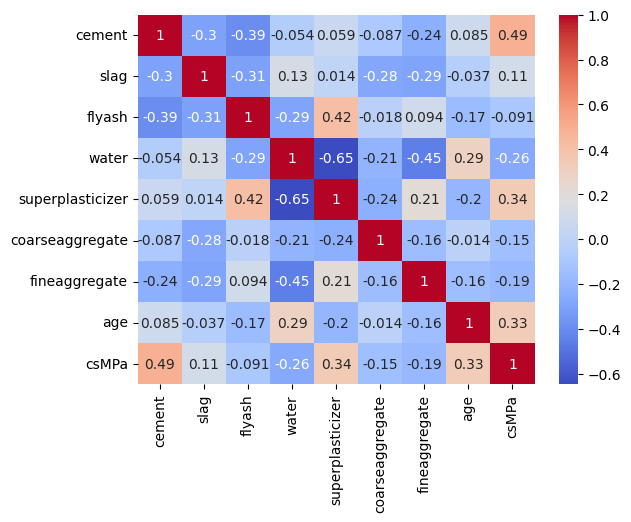

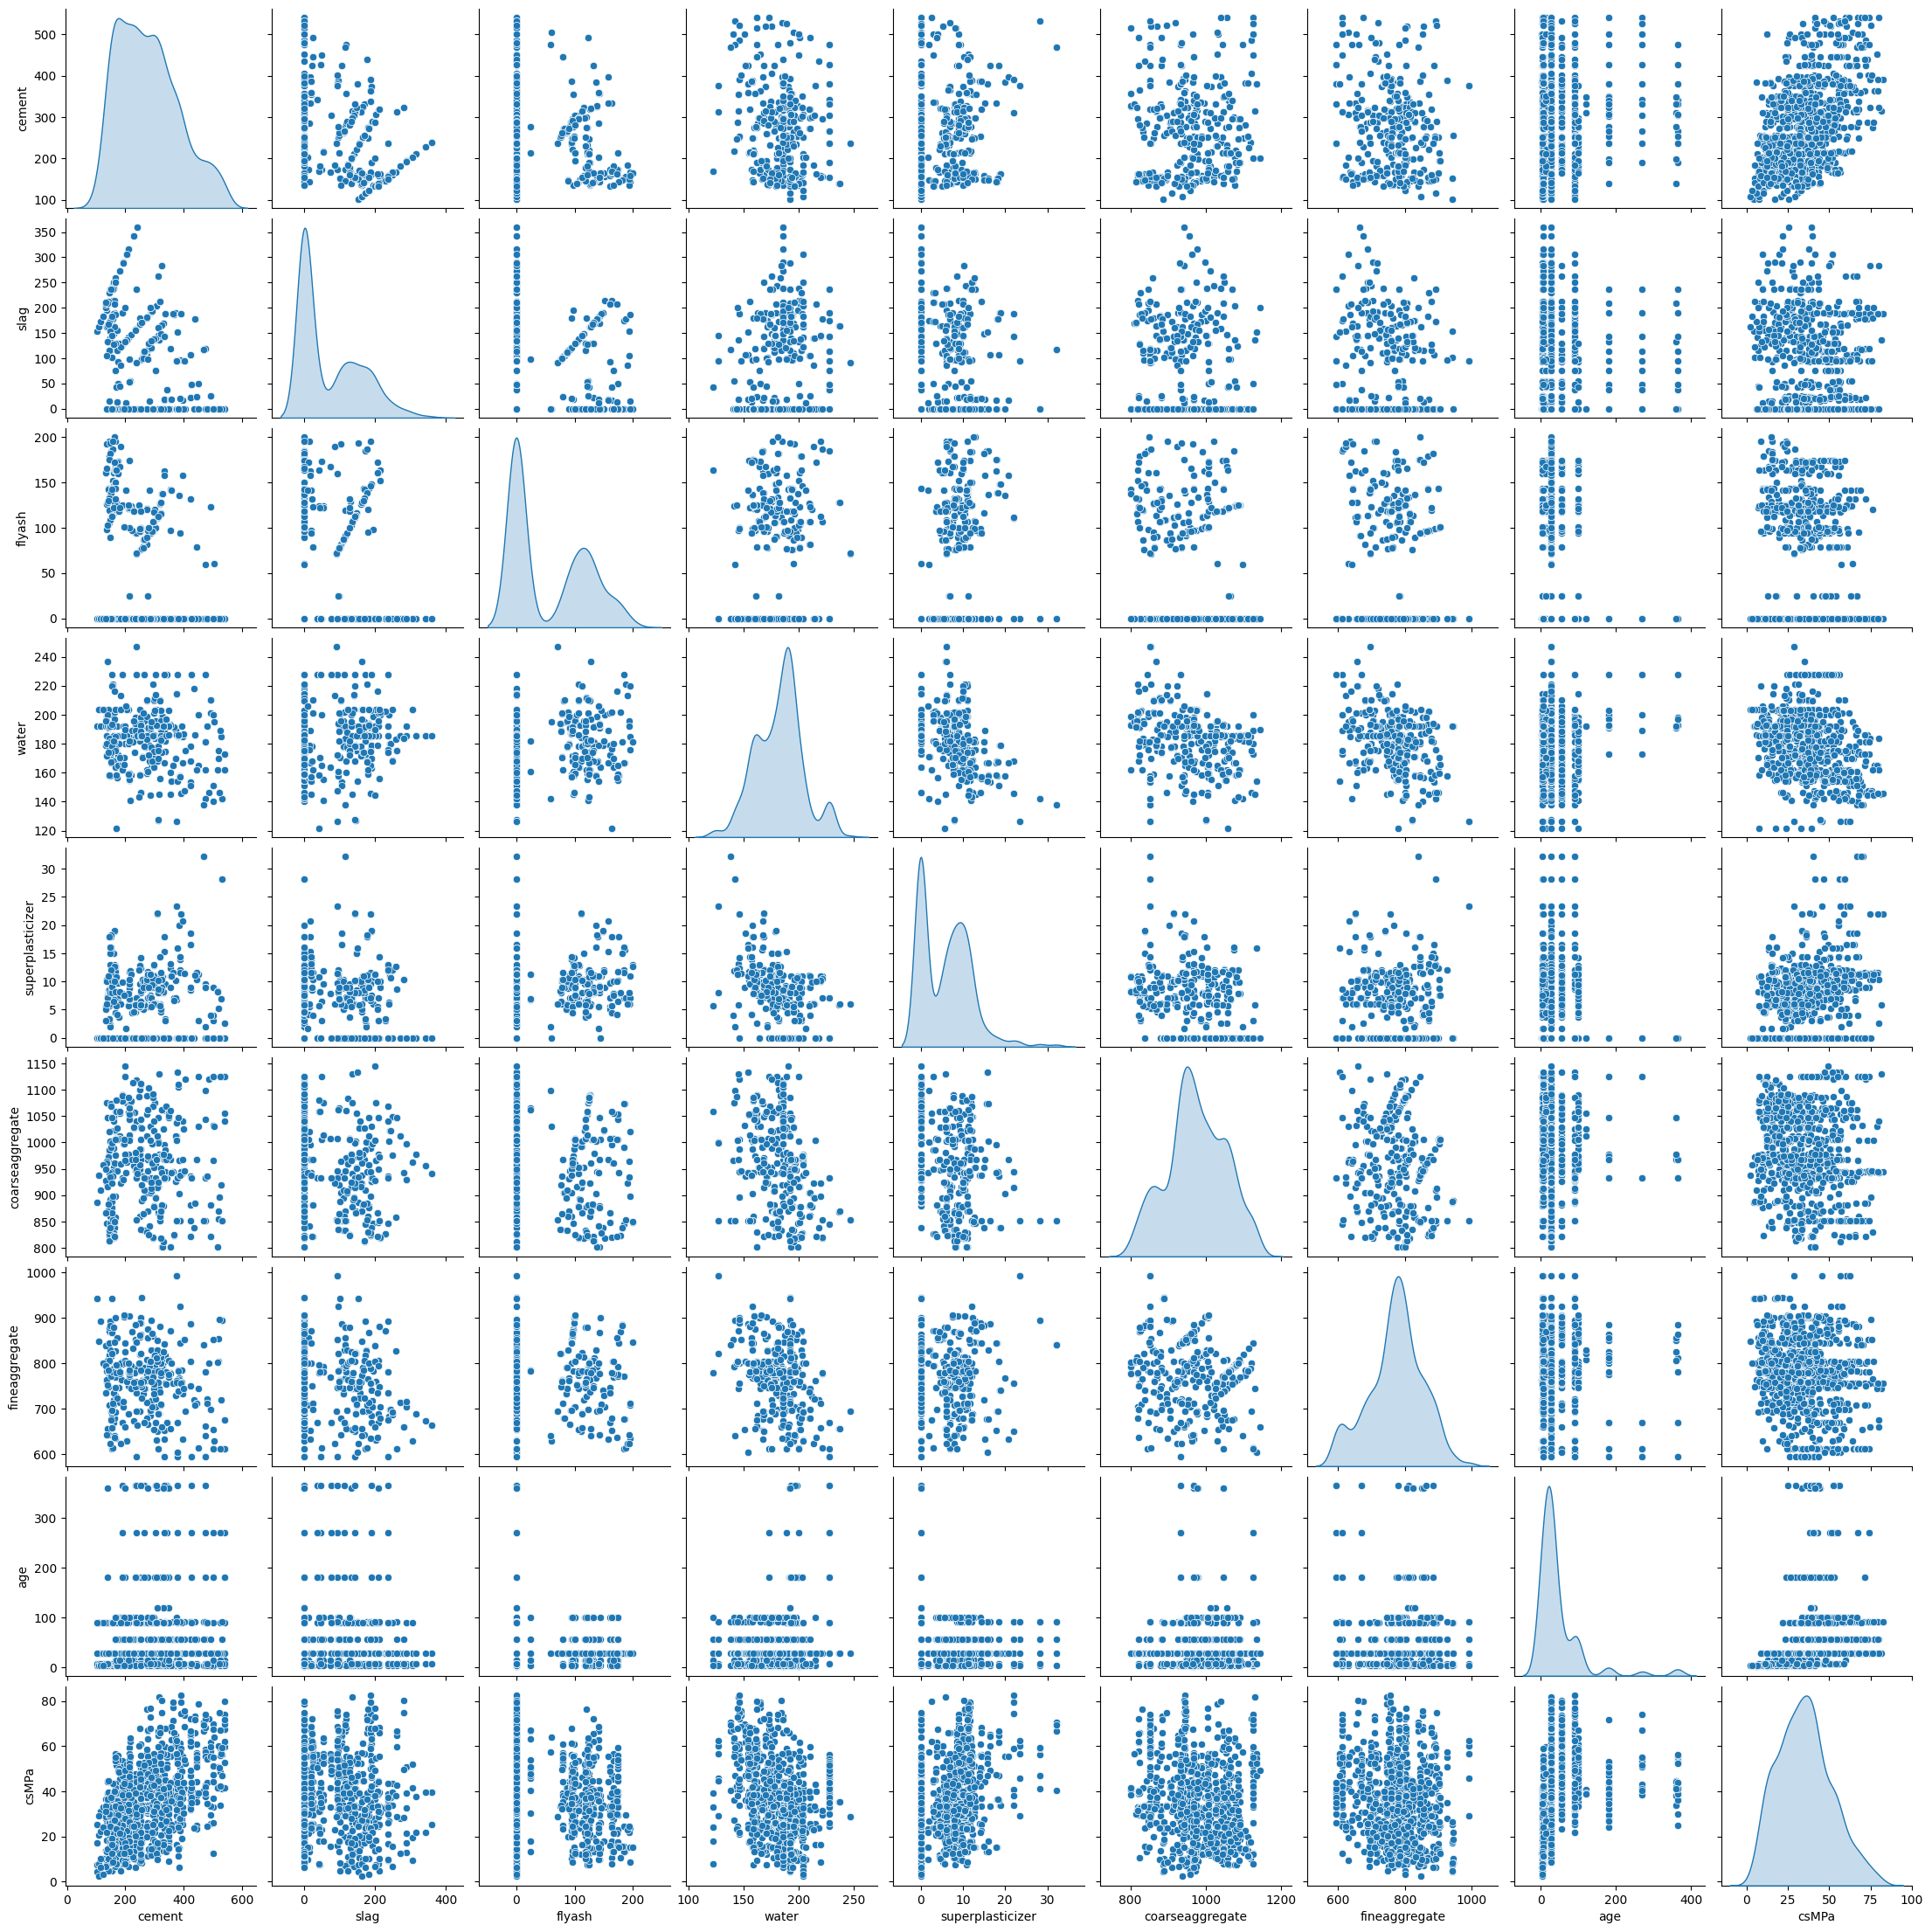

In [19]:
### Zadanie 4 cd.
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

sns.pairplot(data, diag_kind='kde')
plt.show()

In [24]:
### Zadanie 5
X = data.drop(columns=['csMPa'])
y = data['csMPa']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MSE: 25.66


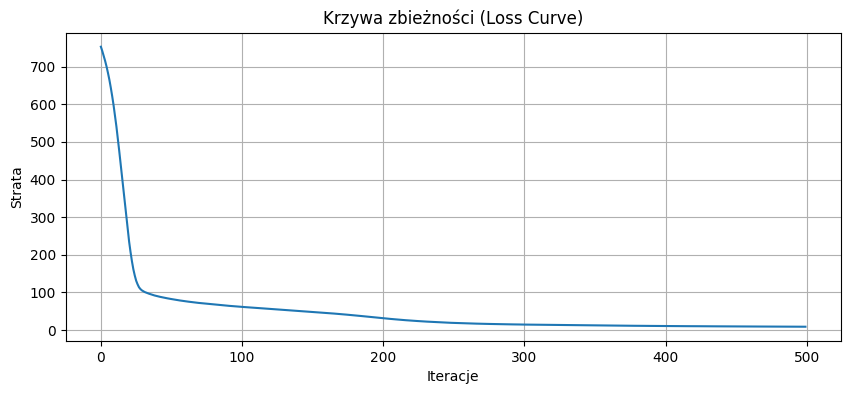

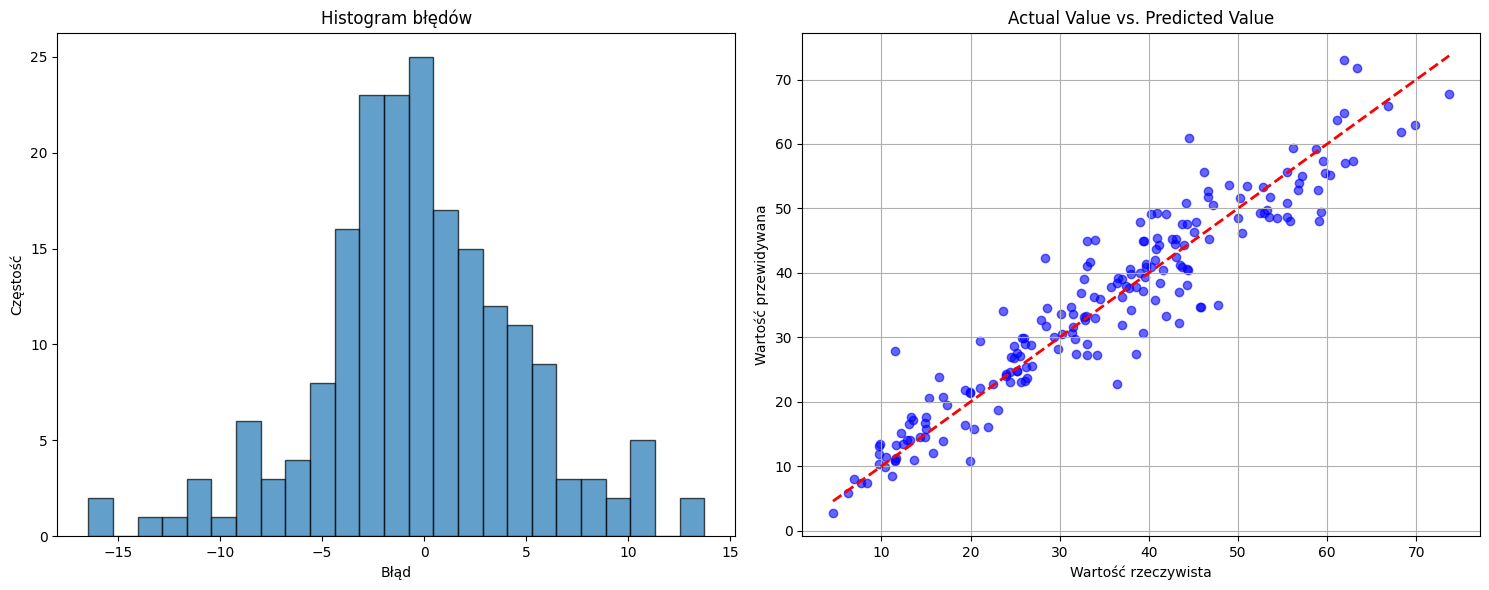

In [30]:
### Zadanie 6
mlp = MLPRegressor(hidden_layer_sizes=(64, 64), activation='relu', solver='adam', max_iter=500, random_state=1)
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(mlp.loss_curve_)
plt.title("Krzywa zbieżności (Loss Curve)")
plt.xlabel("Iteracje")
plt.ylabel("Strata")
plt.grid(True)
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

errors = y_test - y_pred
ax1.hist(errors, bins=25, edgecolor='black', alpha=0.7)
ax1.set_title("Histogram błędów")
ax1.set_xlabel("Błąd")
ax1.set_ylabel("Częstość")

ax2.scatter(y_test, y_pred, alpha=0.6, color='blue')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_title("Actual Value vs. Predicted Value")
ax2.set_xlabel("Wartość rzeczywista")
ax2.set_ylabel("Wartość przewidywana")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
### Zadanie 7
